In [9]:
import torch

from pathlib import Path
from importlib import reload
import numpy as np
from scipy import interpolate

import synthetic_citizen
reload(synthetic_citizen)

import liquid_council
reload(liquid_council)

from liquid_council import LiquidCouncil

import train
reload(train)

import synth_metrics
reload(synth_metrics)

from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap


experiment_name = "20250403_145322_exp_layer_budget_24_1"
folder = Path(".").resolve() / "experiments" / experiment_name

council = LiquidCouncil.load_from_checkpoint(folder)
council = council.to("cuda")

dataset, _ = train.load_data_synthetic(n_train=10_000, n_valid=100)

6 2 2 2
6 2 2 2
6 2 2 2
6 2 2 2


In [10]:
sum(p.numel() for p in council.parameters() if p.requires_grad)

32628

In [44]:
def to_even_plane_values(
    x: np.ndarray,
    y: np.ndarray,
    v: np.ndarray,
    detail: int = 200,
    xlim: tuple[float, float] = (-1, 1),
    ylim: tuple[float, float] = (-1, 1)
    ):

    px = np.linspace(*xlim, detail)
    py = np.linspace(*ylim, detail)

    X, Y = np.meshgrid(px, py)
    interp = interpolate.LinearNDInterpolator(list(zip(x, y)), v)
    Z = interp(X, Y)

    return Z

def to_even_plane_tensors(
    X: torch.Tensor,
    v: torch.Tensor,
    detail: int = 200,
    xlim: tuple[float, float] = (-1, 1),
    ylim: tuple[float, float] = (-1, 1)
):
    return to_even_plane_values(X[:, 0].numpy(), X[:, 1].numpy(), v.numpy(), detail, xlim, ylim)

def plot_Z(Z: np.ndarray, ax: plt.Axes = None, cmap = None, colorbar: bool = False, n_classes: int = -1):

    if cmap is None:
        cmap = ListedColormap(['#1446A0', '#DB3069', '#F5D547'])

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    mappable = ax.imshow(Z, extent=[-1, 1, -1, 1], origin='lower', cmap=cmap, interpolation='nearest')
    ax.set_axis_off()

    if colorbar:
        ticks = None if n_classes == -1 else np.arange(n_classes)
        plt.colorbar(mappable, ticks=ticks)


In [45]:
classifications, Ds, Ps = synth_metrics.inference(council, dataset)

classifications.shape, Ds.shape, Ps.shape

(torch.Size([4, 10000, 3]), torch.Size([10000, 4, 4]), torch.Size([10000, 4]))

In [46]:
synth_metrics.calc_metrics(council, dataset, classifications, Ps, verbal=True)

accuracy 0.924
power_entropy 0.194
speaker_entropy 0.938
region_nmi 0.660


(0.9236, 0.19402363896369934, 0.9380924105644226, 0.6604423689206776)

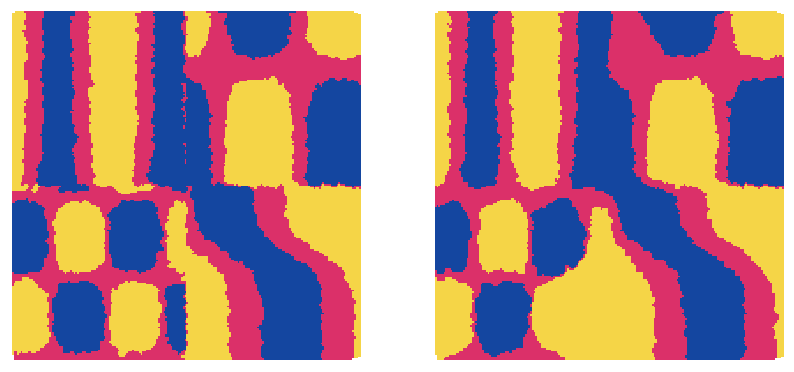

In [47]:
def plot_citizen_coverage():

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    hat = council.vote(classifications, Ps)
    zhat = to_even_plane_tensors(dataset.tensors[0], hat)
    z = to_even_plane_tensors(dataset.tensors[0], dataset.tensors[1])
    plot_Z(z, ax=ax[0])
    plot_Z(zhat, ax=ax[1])
    plt.show()

plot_citizen_coverage()

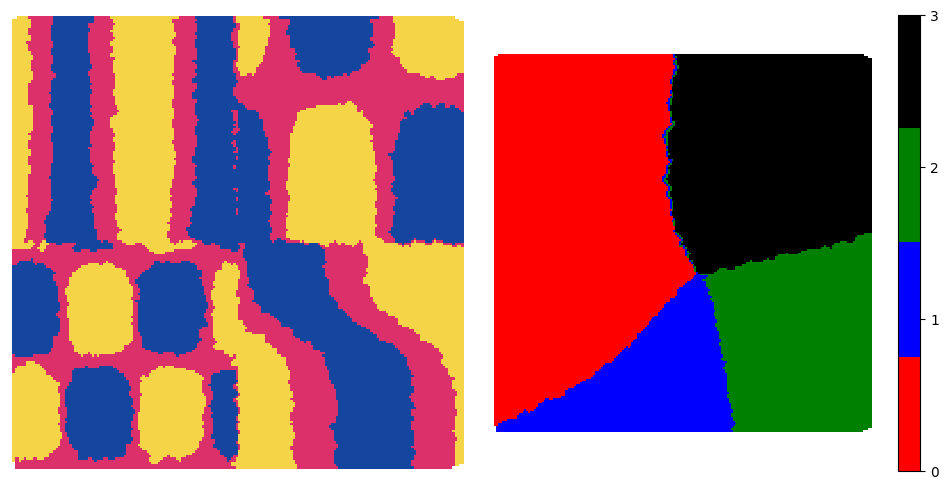

In [48]:
def plot_citizen_coverage():

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    cmap = ListedColormap(['red', 'blue', 'green', "black"])

    hat = torch.argmax(Ps, 1)
    zhat = to_even_plane_tensors(dataset.tensors[0], hat)
    z = to_even_plane_tensors(dataset.tensors[0], dataset.tensors[1])
    plot_Z(z, ax=ax[0])
    plot_Z(zhat, ax=ax[1], cmap=cmap, colorbar=True, n_classes=4)
    fig.tight_layout()
    plt.show()


plot_citizen_coverage()

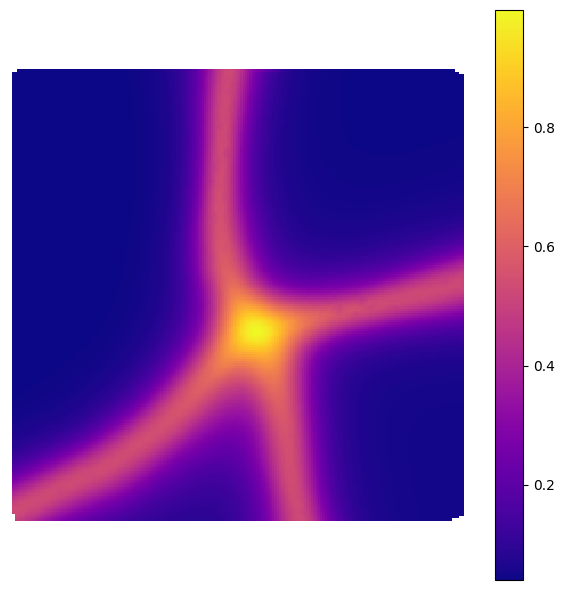

In [49]:
# TODO power entropy plot

from torch.distributions import Categorical
import math
import matplotlib as mpl


def plot_entropy():
    fig, ax = plt.subplots(figsize=(6, 6))

    n = Ps.shape[1]

    dist = Categorical(probs=Ps)
    entropy = dist.entropy() / math.log(n)

    Z = to_even_plane_tensors(dataset.tensors[0], entropy)
    plot_Z(Z, ax=ax, cmap=mpl.colormaps["plasma"], colorbar=True)

    fig.tight_layout()

plot_entropy()

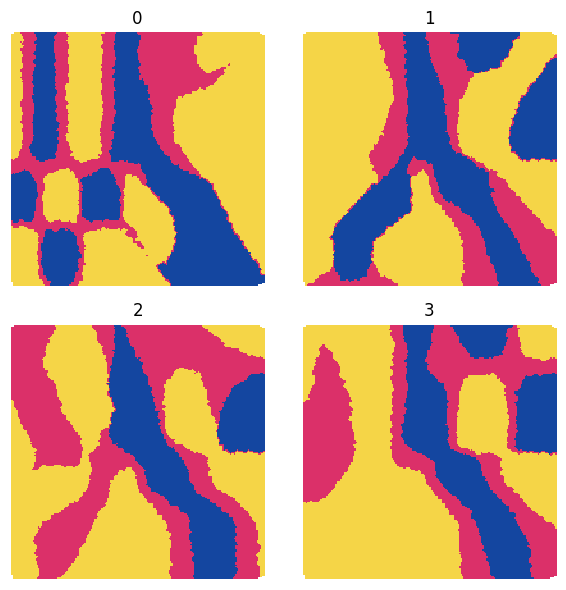

In [50]:
def plot_citizens_perspective():
    fig, axs = plt.subplots(2, 2, figsize=(6, 6))

    for i_citizen, ax in enumerate(axs.ravel()):
        label_hat = torch.argmax(classifications[i_citizen, :, :], dim=1)
        zhat = to_even_plane_tensors(dataset.tensors[0], label_hat)
        plot_Z(zhat, ax=ax)
        ax.set_title(i_citizen)

    fig.tight_layout()
    plt.show()


plot_citizens_perspective()